In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
alphas=[1e-2,1e-3,1e-4]
alphas_str=["1e-2","1e-3","1e-4"]
paths = []
for alpha in alphas_str:
    path = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_a_{alpha}/"
    paths.append(path)

In [10]:

max_n =100
rho_cube=[] # first index: which path, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(path+f"gasdens{i}.dat").reshape(128, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

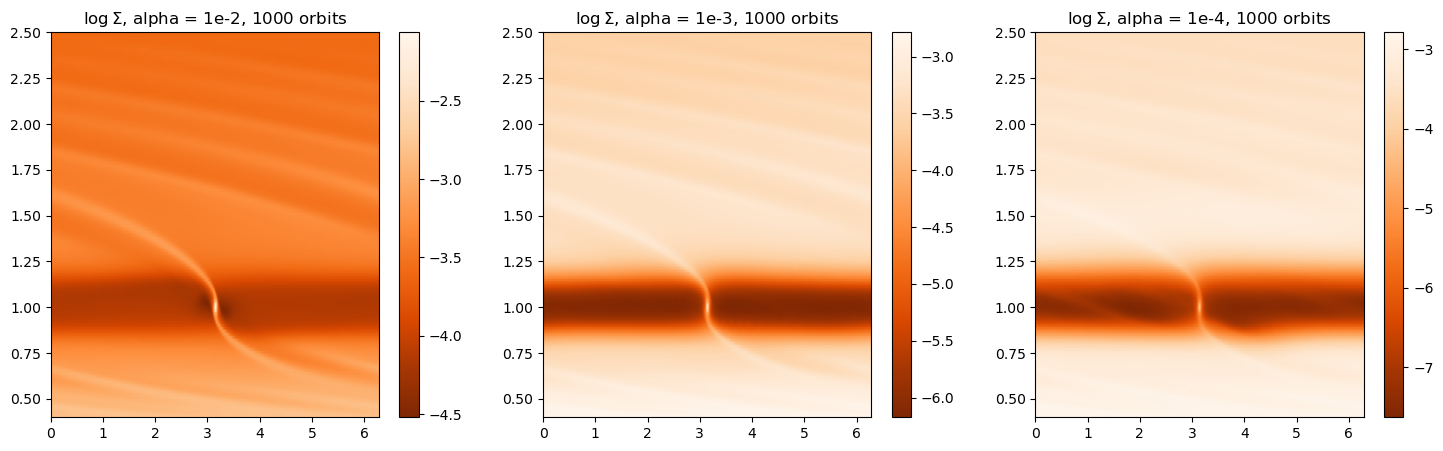

In [11]:
%matplotlib inline

n_frame=max_n
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(np.log10(rho_cube[0][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[0]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(np.log10(rho_cube[1][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[1]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(np.log10(rho_cube[2][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[2]}, {(n_frame)*10} orbits")
plt.colorbar()
plt.show()

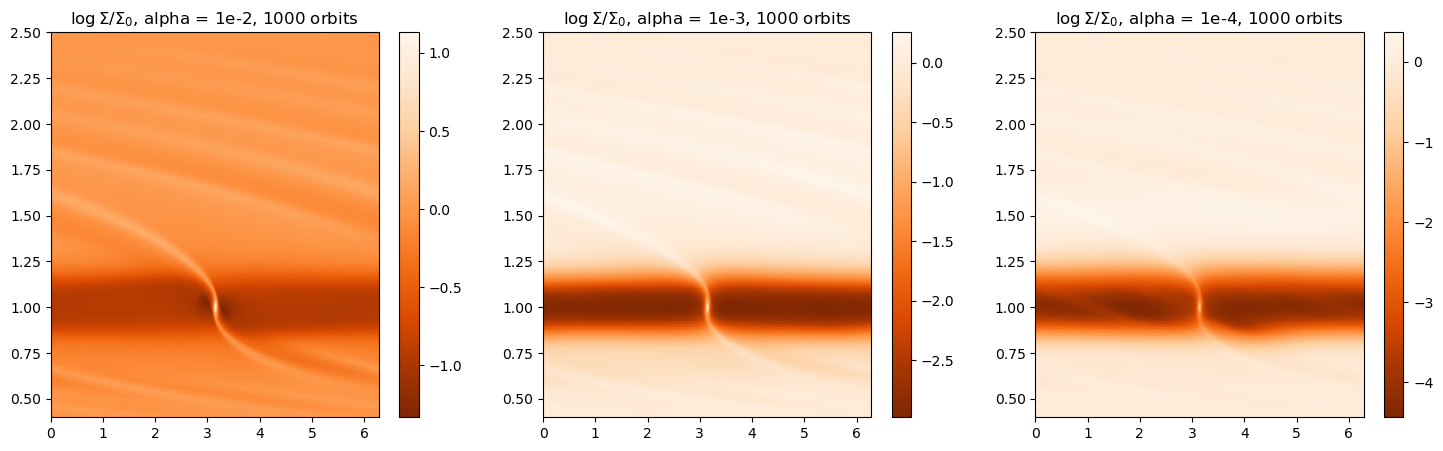

In [12]:
%matplotlib inline

n_frame=max_n
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(np.log10(rho_cube[0][n_frame])-np.log10(rho_cube[0][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[0]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(np.log10(rho_cube[1][n_frame])-np.log10(rho_cube[1][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[1]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(np.log10(rho_cube[2][n_frame])-np.log10(rho_cube[2][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[2]}, {(n_frame)*10} orbits")
plt.colorbar()
plt.show()


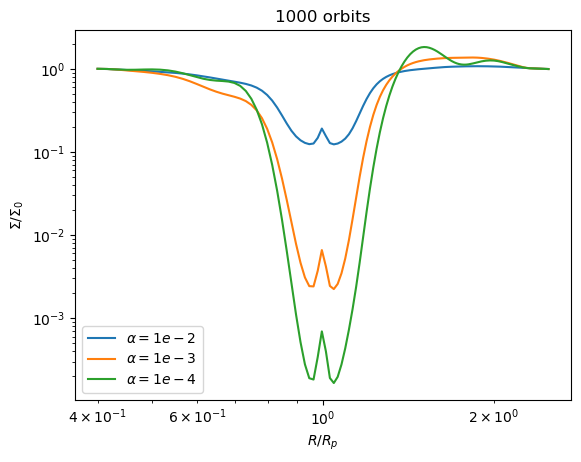

In [13]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
frame=max_n
rlist = np.linspace(Ymin,Ymax, len(rho_cube[0][0]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)
plt.plot(rlist,rho_mean[0][frame]/rho_mean[0][0], label=f"$\\alpha={alphas_str[0]}$")
plt.plot(rlist,rho_mean[1][frame]/rho_mean[1][0], label=f"$\\alpha={alphas_str[1]}$")
plt.plot(rlist,rho_mean[2][frame]/rho_mean[2][0], label=f"$\\alpha={alphas_str[2]}$")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
#plt.ylim(1e-4,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.title(f"{(frame)*10} orbits")
plt.legend()

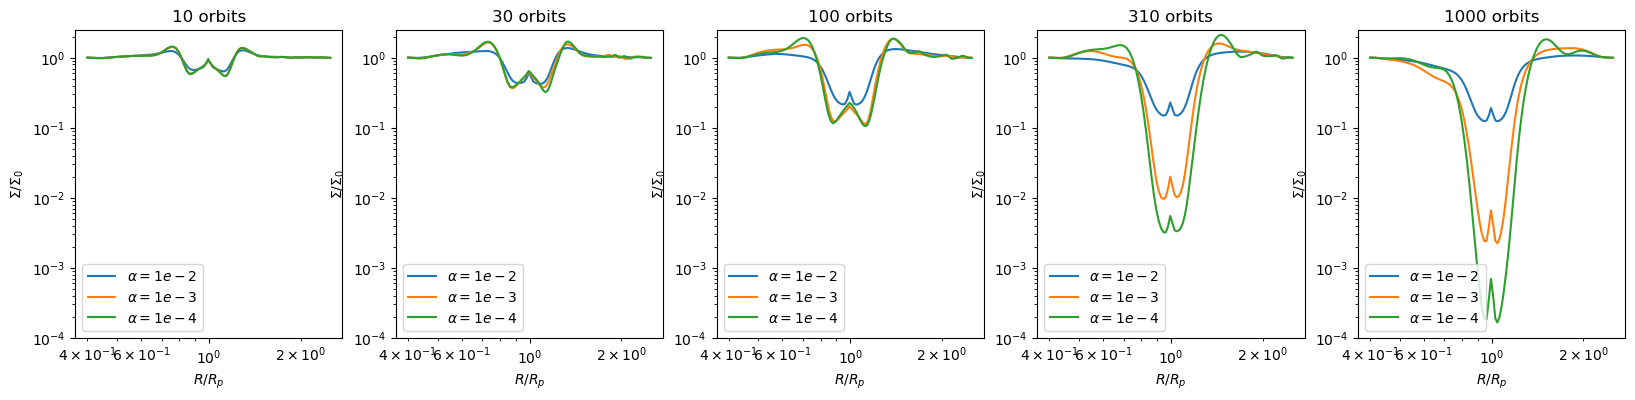

In [15]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
num_fig = 5
rlist = np.linspace(Ymin,Ymax, len(rho_cube[0][0]))
rho_mean = np.mean(rho_cube, axis=3)
frame_num = np.exp(np.log(10)*np.linspace(0,2,5))

plt.figure(figsize=(4*len(frame_num),4))

for i,frame in enumerate(frame_num):
    frame = int(frame)
    plt.subplot(1,len(frame_num),i+1)
    plt.plot(rlist,rho_mean[0][frame]/rho_mean[0][0], label=f"$\\alpha={alphas_str[0]}$")
    plt.plot(rlist,rho_mean[1][frame]/rho_mean[1][0], label=f"$\\alpha={alphas_str[1]}$")
    plt.plot(rlist,rho_mean[2][frame]/rho_mean[2][0], label=f"$\\alpha={alphas_str[2]}$")
    plt.xlabel("$R/R_p$")
    plt.ylabel("$\\Sigma/\\Sigma_0$")
    #plt.ylim(1e-4,2e-3)
    plt.xscale("log")
    plt.yscale("log")
    plt.ylim(1e-4,2.5)
    plt.title(f"{(frame)*10} orbits")
    plt.legend()

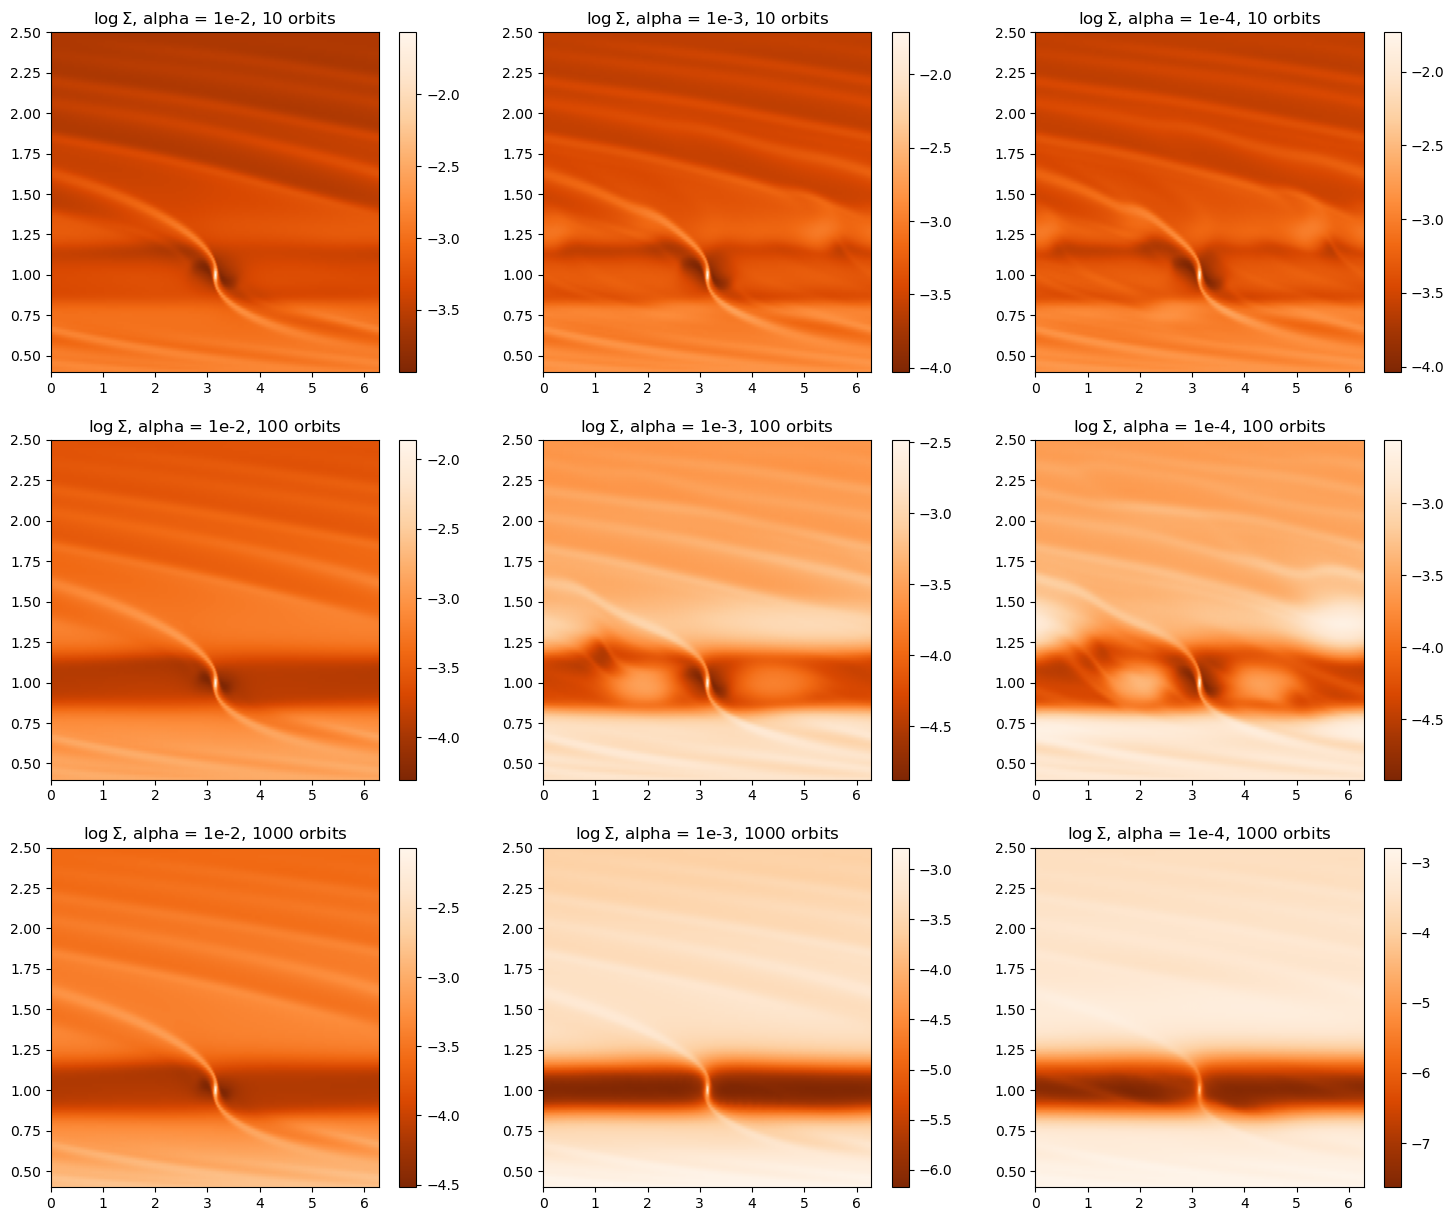

In [16]:
%matplotlib inline
frame_num = [max_n/100,max_n/10, max_n]
plt.figure(figsize=(18,5*len(frame_num)))
for i,n_frame in enumerate(frame_num):
    n_frame=int(n_frame)
    plt.subplot(len(frame_num),3,1+3*i)
    plt.imshow(np.log10(rho_cube[0][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[0]}, {(n_frame)*10} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),3,2+3*i)
    plt.imshow(np.log10(rho_cube[1][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[1]}, {(n_frame)*10} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),3,3+3*i)
    plt.imshow(np.log10(rho_cube[2][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[2]}, {(n_frame)*10} orbits")
    plt.colorbar()

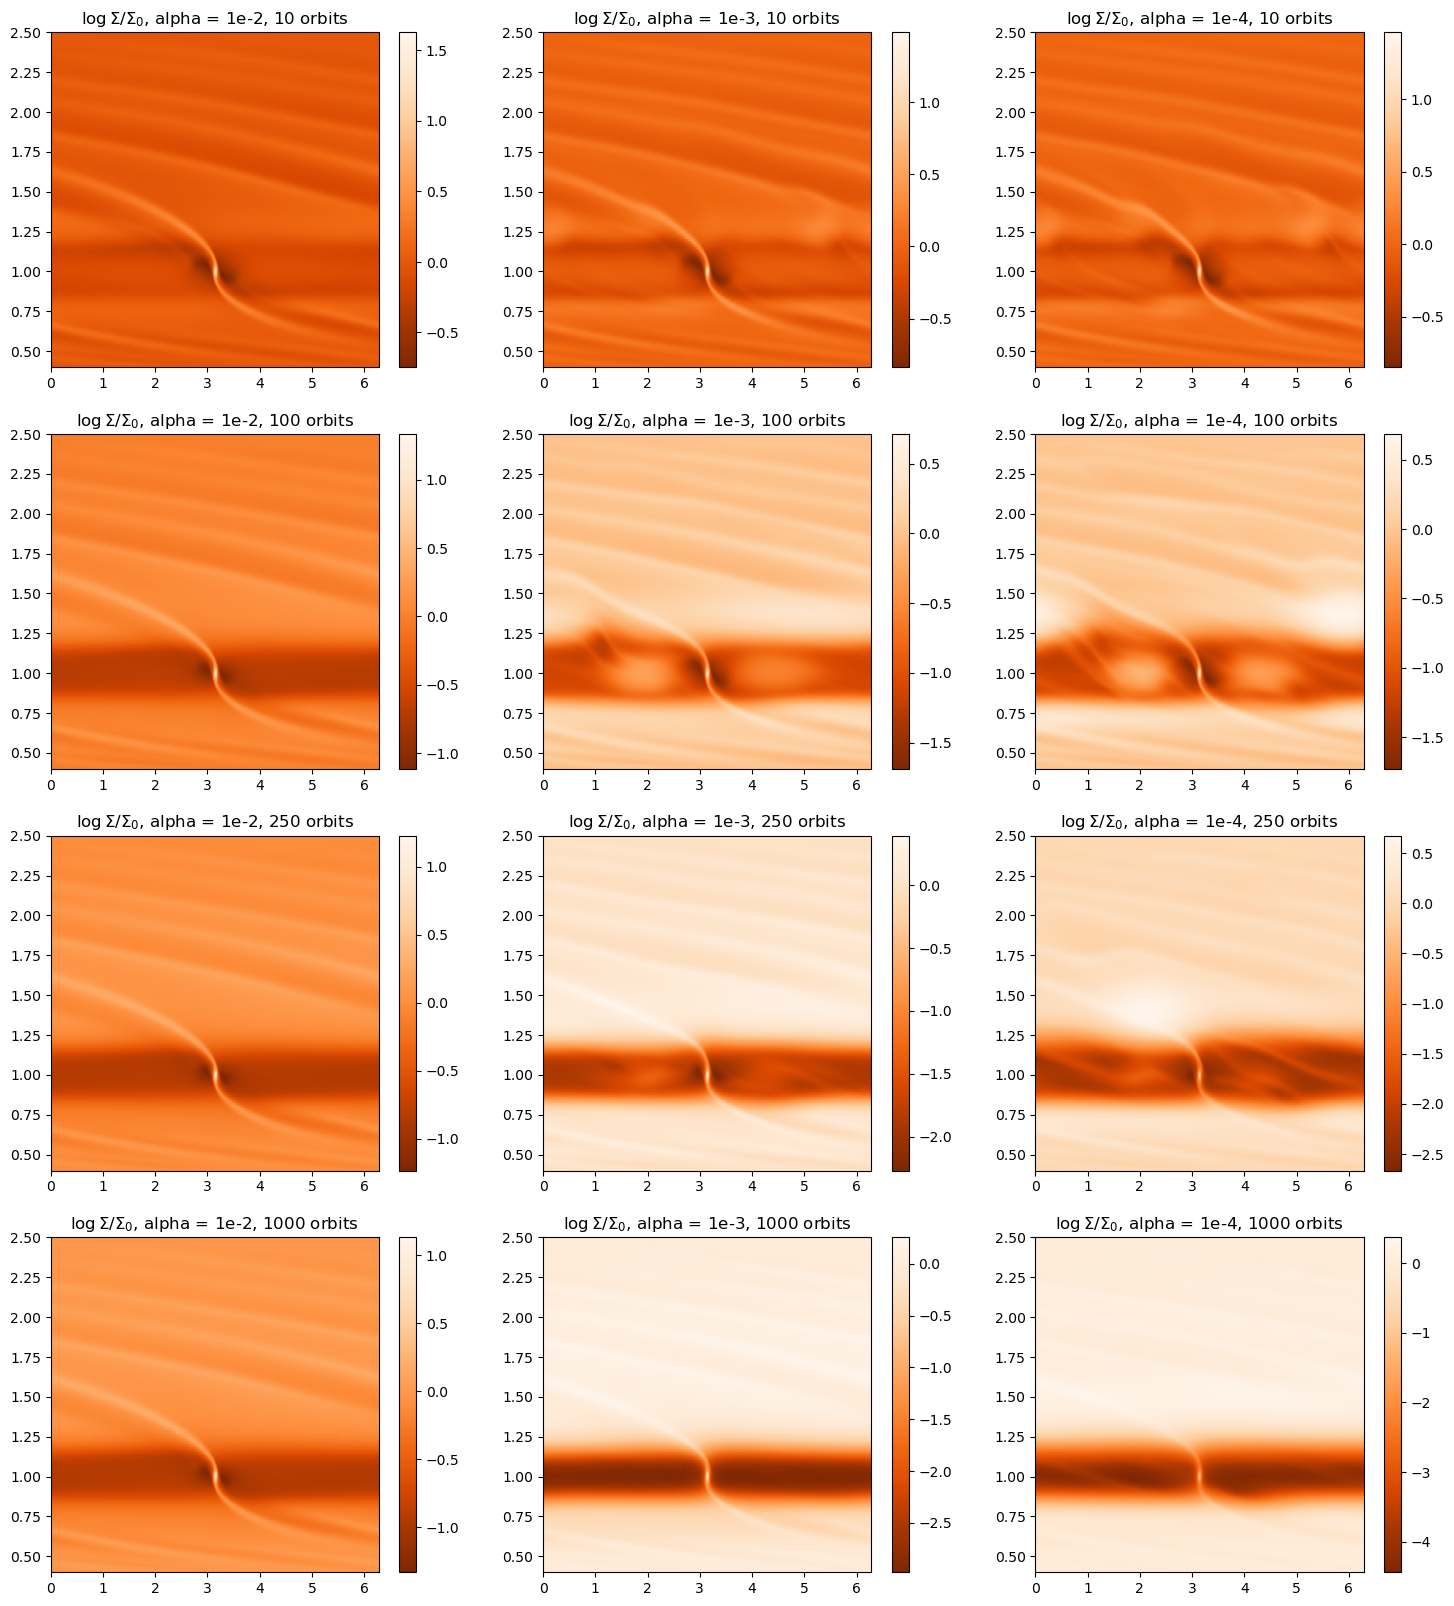

In [19]:
%matplotlib inline
frame_num = [max_n/100,max_n/10, max_n/4, max_n]
plt.figure(figsize=(18,5*len(frame_num)))
for i,n_frame in enumerate(frame_num):
    n_frame=int(n_frame)
    plt.subplot(len(frame_num),3,1+3*i)
    plt.imshow(np.log10(rho_cube[0][n_frame])-np.log10(rho_cube[0][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[0]}, {(n_frame)*10} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),3,2+3*i)
    plt.imshow(np.log10(rho_cube[1][n_frame])-np.log10(rho_cube[1][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[1]}, {(n_frame)*10} orbits")
    plt.colorbar()
    
    plt.subplot(len(frame_num),3,3+3*i)
    plt.imshow(np.log10(rho_cube[2][n_frame])-np.log10(rho_cube[2][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
    plt.title(f"$\\log \\Sigma/\\Sigma_0$, alpha = {alphas_str[2]}, {(n_frame)*10} orbits")
    plt.colorbar()